Importing the Dependencies

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

Data Collection & Analysis

In [ ]:
# loading the diabetes dataset to a pandas DataFrame
diabetes_dataset = pd.read_csv('/content/step2_onehot_encoded_Devinda.csv')

Data Preprocessing - Label Encoding

In [ ]:
# Step 1 - Pre-Encoding Cleaning


# Clean (lowercase and strip)
diabetes_dataset['gender'] = diabetes_dataset['gender'].str.lower().str.strip()

# Handle "other" - Drop negligible rows (only ~0.018% of data)
initial_rows = len(diabetes_dataset)
diabetes_dataset = diabetes_dataset[diabetes_dataset['gender'] != 'other']  # Drop rows where gender == 'other'
dropped_rows = initial_rows - len(diabetes_dataset)
print(f"\nDropped {dropped_rows} rows with 'other' gender (negligible: {dropped_rows/initial_rows*100:.3f}% of data)")

# Verify after dropping
print("\nUnique values in gender after dropping 'other':", diabetes_dataset['gender'].unique())
print("\nOriginal gender distribution (after cleaning & dropping):\n", diabetes_dataset['gender'].value_counts(normalize=True))


Dropped 18 rows with 'other' gender (negligible: 0.022% of data)

Unique values in gender after dropping 'other': ['female' 'male']

Original gender distribution (after cleaning & dropping):
 gender
female    0.584915
male      0.415085
Name: proportion, dtype: float64


In [ ]:
# Step 2 - Apply Label Encoding
X = diabetes_dataset.drop('diabetes', axis=1)
y = diabetes_dataset['diabetes']
le = LabelEncoder()
X['gender_encoded'] = le.fit_transform(X['gender'])
X = X.drop('gender', axis=1)

EDA - Visualizations

In [ ]:
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

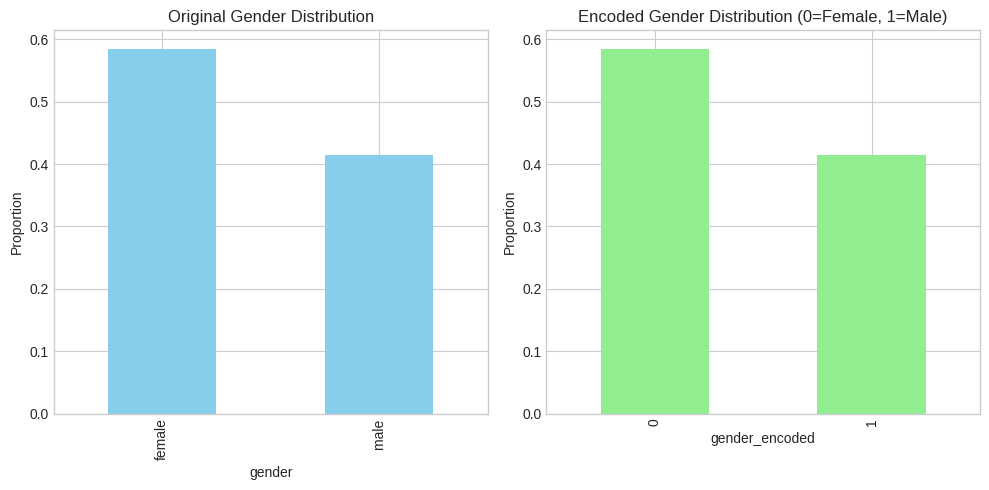

In [ ]:
# Plot 1 - Original vs Encoded Gender Distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
diabetes_dataset['gender'].value_counts(normalize=True).plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Original Gender Distribution')
axes[0].set_ylabel('Proportion')
X['gender_encoded'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Encoded Gender Distribution (0=Female, 1=Male)')
axes[1].set_ylabel('Proportion')
plt.tight_layout()
plt.show()


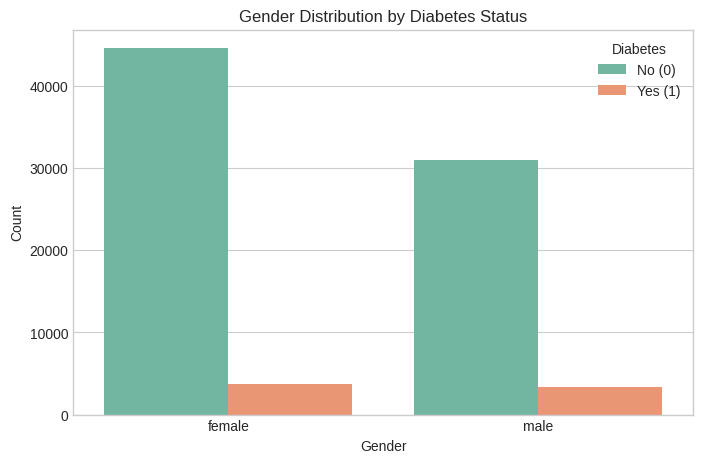

In [ ]:
# Plot 2 - Gender vs Diabetes (Original Data)
plt.figure(figsize=(8, 5))
sns.countplot(data=diabetes_dataset, x='gender', hue='diabetes', palette='Set2')
plt.title('Gender Distribution by Diabetes Status')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Diabetes', labels=['No (0)', 'Yes (1)'])
plt.show()

Post-Encoding Verification

In [ ]:
print("\nEncoded gender distribution:\n", X['gender_encoded'].value_counts(normalize=True))
print("\nUnique values in gender_encoded:", sorted(X['gender_encoded'].unique()))


Encoded gender distribution:
 gender_encoded
0    0.584915
1    0.415085
Name: proportion, dtype: float64

Unique values in gender_encoded: [np.int64(0), np.int64(1)]


Merge Encoded Features with Target Variable

In [ ]:
# Combine encoded features (X) with target variable (y) into one dataset
diabetes_dataset_encoded = pd.concat([X, y], axis=1)

Save the processed CSV

In [ ]:
diabetes_dataset_encoded.to_csv("step3_label_encoded_Dilhani.csv", index=False)
print("Saved with all columns included")


Saved with all columns included
